In [9]:
################################
###   Imports                ###
################################

import sys, os, re, subprocess
from pathlib import Path
import numpy as np
import h5py

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from tqdm.auto import tqdm

################################
###   Project Paths          ###
################################

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent

DATA_DIR = PROJECT_DIR / "data"
PYTHON_DIR = PROJECT_DIR / "python"

DUST_DIR = DATA_DIR / "MWDUST"
IRFS_DIR = DATA_DIR / "IRFs"

PRIOR_ANALYSIS_DIR = DATA_DIR / "prior_analysis"

os.environ["DUST_DIR"] = str(DUST_DIR)

if str(PYTHON_DIR) not in sys.path:
    sys.path.insert(0, str(PYTHON_DIR))

################################
###   Analysis Imports       ###
################################

import JWST_Line_Model as jlm
from likelihood import build_dimensionless_bin_edges

################################
###   Analysis Setup         ###
################################

SPEED_OF_LIGHT = 299_792.0
REFERENCE_COUPLING = 1e-11
DELTA_CHI2 = 4.0 # 2503.11753 uses a two sigma limit

VELOCITY_PARAMETERS = {"v_0": 220.0 / SPEED_OF_LIGHT}

################################
###   Instrument Config      ###
################################

INSTRUMENT_CONFIG = {
    "MIRI": {
        "data_file": "miri_data.jld2",
        "bounds_file": "bounds_miri.csv",
        "n_masses": 50,
        "mass_ticks": [0.1, 0.2, 0.3, 0.5],
        "ylim": (3e-14, 1e-8),
    },

    "NIRSpec": {
        "data_file": "nirspec_data.jld2",
        "bounds_file": "bounds_nirspec.csv",
        "n_masses": 150,
        "mass_ticks": [0.5, 1, 2, 4],
        "ylim": (3e-14, 1e-8),
    },


}

# Restrict to a subset here to run a single instrument
INSTRUMENTS = list(INSTRUMENT_CONFIG)

################################
###   Line Models            ###
################################

def make_line_model(instrument):

    model = jlm.Line_Forward_Model(IRFs_file_loc=str(IRFS_DIR) + os.sep)
    model.set_instrument(instrument)

    if instrument == "NIRSpec":
        model.set_gratings()

    model.set_extinction_law("None")

    return model


line_models = {instrument: make_line_model(instrument) for instrument in INSTRUMENTS}

In [2]:
################################
###   Prior Analysis Data    ###
################################

PRIOR_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

JWST_DATA_REPO = PRIOR_ANALYSIS_DIR / "JWST-data"
RELEASE_URL = "https://github.com/elenapinetti/JWST-data/releases/download/v1.0/"

data_paths = {
    instrument: PRIOR_ANALYSIS_DIR / INSTRUMENT_CONFIG[instrument]["data_file"]
    for instrument in INSTRUMENTS
}

bounds_paths = {
    instrument: JWST_DATA_REPO / INSTRUMENT_CONFIG[instrument]["bounds_file"]
    for instrument in INSTRUMENTS
}

################################
###   Clone Data Repository  ###
################################

if not JWST_DATA_REPO.exists():

    subprocess.run(
        ["git", "clone", "--depth", "1", "https://github.com/elenapinetti/JWST-data"],
        cwd=PRIOR_ANALYSIS_DIR,
        check=True,
    )

################################
###   Download Spectra       ###
################################

for instrument in INSTRUMENTS:

    if not data_paths[instrument].exists():

        subprocess.run(
            ["curl", "-L", "-o", str(data_paths[instrument]),
             RELEASE_URL + INSTRUMENT_CONFIG[instrument]["data_file"]],
            check=True,
        )

################################
###   Confirm Inputs         ###
################################

for instrument in INSTRUMENTS:
    print(f"{instrument} data:  {data_paths[instrument]}")
    print(f"{instrument} bound: {bounds_paths[instrument]}")

MIRI data:  /global/scratch/projects/pc_heptheory/jfoster/DarkJWST/data/prior_analysis/miri_data.jld2
MIRI bound: /global/scratch/projects/pc_heptheory/jfoster/DarkJWST/data/prior_analysis/JWST-data/bounds_miri.csv
NIRSpec data:  /global/scratch/projects/pc_heptheory/jfoster/DarkJWST/data/prior_analysis/nirspec_data.jld2
NIRSpec bound: /global/scratch/projects/pc_heptheory/jfoster/DarkJWST/data/prior_analysis/JWST-data/bounds_nirspec.csv


In [3]:
################################
###   HDF5 Loader            ###
################################

def dereference_hdf5(f, value):

    if isinstance(value, h5py.Reference):
        value = f[value][()]

    if isinstance(value, bytes):
        return value.decode("utf-8")

    if isinstance(value, np.ndarray):

        if value.shape == ():
            return dereference_hdf5(f, value.item())

        if value.dtype == np.uint8:
            return bytes(value).decode("utf-8")

    return value


def load_spectra(path):

    with h5py.File(path, "r") as f:

        names = np.asarray([dereference_hdf5(f, value) for value in f["fits_name"][:]])

        wavelength = [np.asarray(dereference_hdf5(f, value), dtype=np.float64) for value in f["wavelength"][:]]
        error = [np.asarray(dereference_hdf5(f, value), dtype=np.float64) for value in f["error"][:]]

        # NIRSpec spectra carry a grating label; MIRI files have none
        grating = None
        if "grating" in f:
            grating = np.asarray([dereference_hdf5(f, value) for value in f["grating"][:]])

        galactic_l = np.degrees(np.asarray(f["l"][:], dtype=np.float64))
        galactic_b = np.degrees(np.asarray(f["b"][:], dtype=np.float64))
        exposure = np.asarray(f["duration"][:], dtype=np.float64)

    return {
        "names": names,
        "wavelength": wavelength,
        "error": error,
        "grating": grating,
        "l": galactic_l,
        "b": galactic_b,
        "exposure": exposure,
        "wavelength_min": np.asarray([values[0] for values in wavelength]),
        "wavelength_max": np.asarray([values[-1] for values in wavelength]),
    }


################################
###   Load Spectra           ###
################################

data = {instrument: load_spectra(data_paths[instrument]) for instrument in INSTRUMENTS}

################################
###   Summary                ###
################################

for instrument in INSTRUMENTS:

    d = data[instrument]

    print(f"{instrument}")
    print(f"  Spectra:             {len(d['names'])}")
    print(f"  Total exposure:      {np.sum(d['exposure']) / 3600:,.0f} hr")
    print(
        f"  Wavelength coverage: "
        f"{np.min(d['wavelength_min']):.2f} -- "
        f"{np.max(d['wavelength_max']):.2f} micron"
    )

    if d["grating"] is not None:
        for name, count in zip(*np.unique(d["grating"], return_counts=True)):
            print(f"    {name:6s}: {count}")

    print()

MIRI
  Spectra:             15419
  Total exposure:      3,770 hr
  Wavelength coverage: 4.89 -- 28.63 micron

NIRSpec
  Spectra:             3639
  Total exposure:      1,064 hr
  Wavelength coverage: 0.60 -- 5.30 micron
    G140H : 471
    G140M : 175
    G235H : 1020
    G235M : 196
    G395H : 1049
    G395M : 385
    PRISM : 343



In [4]:
################################
###   Published Limits       ###
################################

published_mass = {}
published_gagg = {}

for instrument in INSTRUMENTS:

    published = np.loadtxt(bounds_paths[instrument], delimiter=",", skiprows=1)

    published_mass[instrument] = published[:, 0]
    published_gagg[instrument] = published[:, 1]

################################
###   Analysis Mass Grids    ###
################################

masses = {}
published_gagg_interp = {}

for instrument in INSTRUMENTS:

    hc = line_models[instrument].hc
    d = data[instrument]

    mass_min = max(np.min(published_mass[instrument]), 2.0 * hc / np.max(d["wavelength_max"]))
    mass_max = min(np.max(published_mass[instrument]), 2.0 * hc / np.min(d["wavelength_min"]))

    masses[instrument] = np.geomspace(mass_min, mass_max, INSTRUMENT_CONFIG[instrument]["n_masses"])

    published_gagg_interp[instrument] = np.interp(
        masses[instrument], published_mass[instrument], published_gagg[instrument]
    )

    print(f"{instrument}: {mass_min:.4f} -- {mass_max:.4f} eV in {len(masses[instrument])} points")

MIRI: 0.0890 -- 0.5000 eV in 50 points
NIRSpec: 0.4680 -- 4.1000 eV in 150 points


In [5]:
################################
###   Dataset Selection      ###
################################

# NIRSpec spectra with known reduction pathologies
PATHOLOGICAL_NAMES = {
    "jw01409-o133_t011_nirspec_prism-clear_x1d.fits",
    "jw01409-o218_t011_nirspec_prism-clear_x1d.fits",
    "jw01409018001_02101_00001_nrs1_x1d.fits",
    "jw01409018001_02101_00002_nrs1_x1d.fits",
    "jw01409018001_02101_00003_nrs1_x1d.fits",
    "jw01409133001_02101_00001_nrs1_x1d.fits",
    "jw01409218001_02101_00002_nrs1_x1d.fits",
    "jw01409218001_02101_00003_nrs1_x1d.fits",
    "jw01947-c1008_t015_nirspec_g395m-f290lp_x1d.fits",
    "jw01947-c1010_t015_nirspec_g395m-f290lp_x1d.fits",
}


def build_sample_masks(instrument, d):

    masks = {"all": np.ones(len(d["names"]), dtype=bool)}

    if instrument != "NIRSpec":
        return masks

    is_pathological = np.asarray([name in PATHOLOGICAL_NAMES for name in d["names"]])
    is_stage3 = np.asarray([bool(re.match(r"^jw\d{5}-[oc]", name)) for name in d["names"]])
    is_ctype = np.asarray([bool(re.match(r"^jw\d{5}-c", name)) for name in d["names"]])

    masks["quality"] = ~is_pathological
    masks["nonprism"] = masks["quality"] & is_stage3 & ~is_ctype & (d["grating"] != "PRISM")
    masks["prism"] = masks["quality"] & is_stage3 & ~is_ctype & (d["grating"] == "PRISM")

    return masks


sample_masks = {instrument: build_sample_masks(instrument, data[instrument]) for instrument in INSTRUMENTS}

for instrument in INSTRUMENTS:
    for label, mask in sample_masks[instrument].items():
        print(f"{instrument} {label:10s}: {np.sum(mask)} spectra")

MIRI all       : 15419 spectra
NIRSpec all       : 3639 spectra
NIRSpec quality   : 3629 spectra
NIRSpec nonprism  : 278 spectra
NIRSpec prism     : 48 spectra


In [6]:
################################
###   Information Floor      ###
################################

def compute_information(model, mass_grid, d):

    # Information per (mass, dataset) at the reference coupling; the sample
    # subsets are summed from this afterwards, so each dataset is modeled once.
    information = np.zeros((len(mass_grid), len(d["names"])), dtype=np.float64)

    for mass_index, mass in enumerate(tqdm(mass_grid, desc="Masses", unit="mass")):

        line_wavelength = 2.0 * model.hc / mass

        available = np.flatnonzero(
            (d["wavelength_min"] < line_wavelength) & (d["wavelength_max"] > line_wavelength)
        )

        for dataset_index in tqdm(available, desc=f"Datasets (m = {mass:.3f} eV)", unit="dataset", leave=False):

            wl = d["wavelength"][dataset_index]
            err = d["error"][dataset_index]
            grating = d["grating"][dataset_index] if d["grating"] is not None else None

            line_fwhm = model.line_FWHM(mass, grating, **VELOCITY_PARAMETERS)

            fit_min = line_wavelength - 5.0 * line_fwhm
            fit_max = line_wavelength + 5.0 * line_fwhm
            i0, i1 = np.searchsorted(wl, [fit_min, fit_max])

            # Exclude datasets with only one wavelength bin in the ROI
            if i1 - i0 < 2: continue

            wl_fit = wl[i0:i1]
            err_fit = err[i0:i1]

            valid = np.isfinite(err_fit) & (err_fit > 0.0)

            if not np.any(valid):
                continue

            bin_edges = build_dimensionless_bin_edges(wl_fit, mass, model.hc)

            signal = model.forward_model(bin_edges, d["l"][dataset_index], d["b"][dataset_index],
                                         REFERENCE_COUPLING, mass, grating, **VELOCITY_PARAMETERS)

            information[mass_index, dataset_index] = np.sum((signal[valid] / err_fit[valid])**2)

    return information


################################
###   Calculate Samples      ###
################################

information = {}

for instrument in INSTRUMENTS:

    print(f"\nCalculating {instrument}")

    per_dataset = compute_information(line_models[instrument], masses[instrument], data[instrument])

    information[instrument] = {
        label: per_dataset[:, mask].sum(axis=1)
        for label, mask in sample_masks[instrument].items()
    }


Calculating MIRI


Masses:   0%|          | 0/50 [00:00<?, ?mass/s]

Datasets (m = 0.089 eV):   0%|          | 0/2580 [00:00<?, ?dataset/s]

Datasets (m = 0.092 eV):   0%|          | 0/2597 [00:00<?, ?dataset/s]

Datasets (m = 0.095 eV):   0%|          | 0/2577 [00:00<?, ?dataset/s]

...

Datasets (m = 3.868 eV):   0%|          | 0/335 [00:00<?, ?dataset/s]

Datasets (m = 3.925 eV):   0%|          | 0/329 [00:00<?, ?dataset/s]

Datasets (m = 3.982 eV):   0%|          | 0/326 [00:00<?, ?dataset/s]

Datasets (m = 4.041 eV):   0%|          | 0/304 [00:00<?, ?dataset/s]

Datasets (m = 4.100 eV):   0%|          | 0/280 [00:00<?, ?dataset/s]

In [7]:
################################
###   Coupling Floors        ###
################################

g_floor = {
    instrument: {
        label: REFERENCE_COUPLING * (DELTA_CHI2 / np.maximum(values, 1e-300))**0.25
        for label, values in information[instrument].items()
    }
    for instrument in INSTRUMENTS
}

################################
###   Comparison             ###
################################

for instrument in INSTRUMENTS:
    for label, floor in g_floor[instrument].items():
        ratio = floor / published_gagg_interp[instrument]
        print(f"{instrument} {label:10s}: median floor/published = {np.median(ratio):.2f}")

MIRI all       : median floor/published = 20.29
NIRSpec all       : median floor/published = 0.18
NIRSpec quality   : median floor/published = 9.05
NIRSpec nonprism  : median floor/published = 15.97
NIRSpec prism     : median floor/published = 15.99


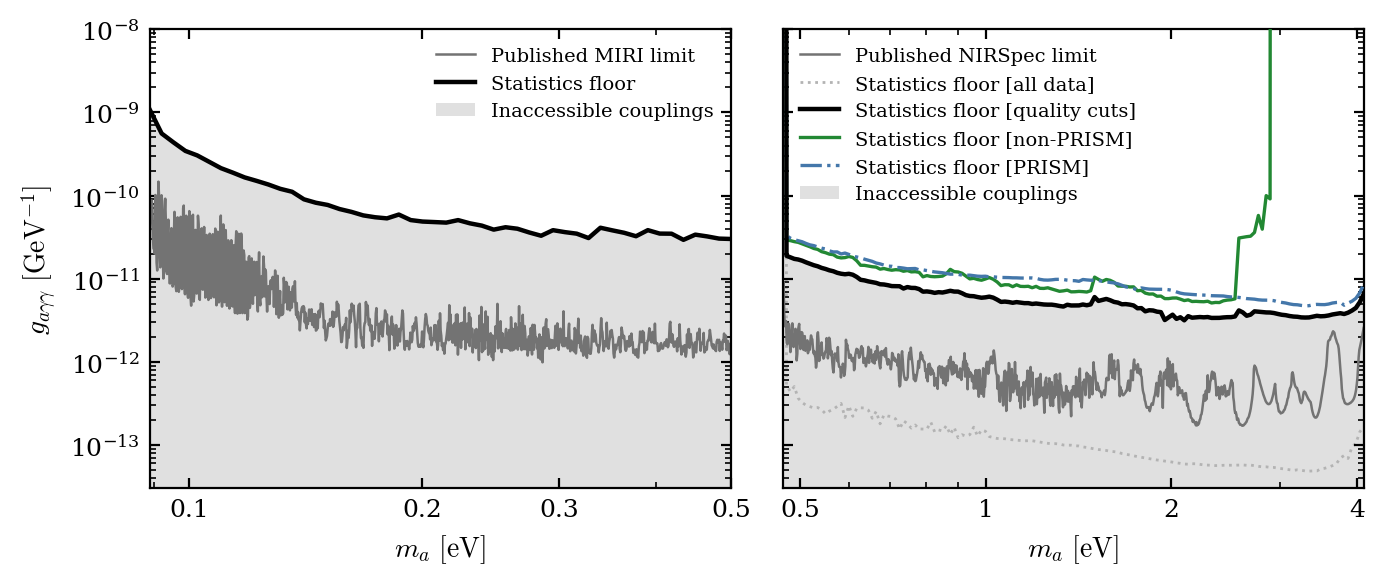

In [12]:
################################
###   Plot Information Floor ###
################################

PLOT_STYLE = {
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 9,
    "axes.labelsize": 10,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
}

# The primary sample is drawn black with the inaccessible region shaded beneath it
PRIMARY_STYLE = dict(color="black", lw=1.6, zorder=4)

SAMPLE_STYLES = {
    "all": dict(color="0.70", lw=1.0, ls=":", zorder=1),
    "nonprism": dict(color="#228833", lw=1.2, zorder=3),
    "prism": dict(color="#4477AA", lw=1.2, ls="-.", zorder=3),
}

SAMPLE_LABELS = {
    "all": "all data",
    "quality": "quality cuts",
    "nonprism": "non-PRISM",
    "prism": "PRISM",
}

with plt.rc_context(PLOT_STYLE):

    fig, axes = plt.subplots(1, len(INSTRUMENTS), figsize=(3.5 * len(INSTRUMENTS), 3.0), dpi=200)
    axes = np.atleast_1d(axes)

    for ax, instrument in zip(axes, INSTRUMENTS):

        config = INSTRUMENT_CONFIG[instrument]
        floors = g_floor[instrument]
        primary = "quality" if "quality" in floors else "all"

        # Published results from 2503.11753
        ax.plot(published_mass[instrument], published_gagg[instrument],
                color="0.45", lw=0.9, label=f"Published {instrument} limit", zorder=2)

        # Information floors
        for label, floor in floors.items():

            style = PRIMARY_STYLE if label == primary else SAMPLE_STYLES[label]
            text = "Statistics floor" if len(floors) == 1 else f"Statistics floor [{SAMPLE_LABELS[label]}]"

            ax.plot(masses[instrument], floor, label=text, **style)

        ax.fill_between(masses[instrument], 1e-14, floors[primary],
                        color="0.88", lw=0.0, zorder=0, label="Inaccessible couplings")

        # Formatting
        ax.set_yscale("log")
        ax.set_ylim(*config["ylim"])

        ax.set_xscale("log")
        ax.set_xlim(np.min(masses[instrument]), np.max(masses[instrument]))
        ax.set_xticks(config["mass_ticks"])
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f"{value:g}"))
        ax.xaxis.set_minor_formatter(mticker.NullFormatter())

        ax.set_xlabel(r"$m_a\ [\mathrm{eV}]$")

        if instrument == 'MIRI':
            ax.set_ylabel(r"$g_{a\gamma\gamma}\ [\mathrm{GeV}^{-1}]$")
        else:
            ax.set_yticklabels([])
        ax.legend(frameon=False)

    fig.tight_layout()
    plt.show()